# How does workload affect performance?

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
(outing_data := pl.read_parquet('data/outing_table.parquet')).head(4)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124


In [3]:
# 1. Pitch count distribution across all outings
pitch_count_stats = outing_data['pitch_count'].describe()
print(pitch_count_stats)

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 36615.0   │
│ null_count ┆ 0.0       │
│ mean       ┆ 17.122491 │
│ std        ┆ 8.146266  │
│ min        ┆ 1.0       │
│ 25%        ┆ 12.0      │
│ 50%        ┆ 16.0      │
│ 75%        ┆ 21.0      │
│ max        ┆ 99.0      │
└────────────┴───────────┘


In [4]:
# 2. Does velocity drop as pitch count increases in the same outing?
from plotnine import *

pitch_count_bins = outing_data.with_columns([
    pl.when(pl.col('pitch_count') <= 10)
      .then(pl.lit('1-10'))
      .when(pl.col('pitch_count') <= 20)
      .then(pl.lit('11-20'))
      .when(pl.col('pitch_count') <= 30)
      .then(pl.lit('21-30'))
      .otherwise(pl.lit('31+'))
      .alias('pitch_count_bin')
])

velo_by_pitch_count = (pitch_count_bins
    .group_by('pitch_count_bin')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo_dev'),
        pl.col('velo_deviation').std().alias('std_velo_dev'),
        pl.len().alias('count'),
    ])
    .with_columns([
        (pl.col('std_velo_dev') / pl.col('count').sqrt()).alias('se')
    ])
    .to_pandas()
)

# Set proper order for x-axis
velo_by_pitch_count['pitch_count_bin'] = pd.Categorical(
    velo_by_pitch_count['pitch_count_bin'], 
    categories=['1-10', '11-20', '21-30', '31+'], 
    ordered=True
)

print(velo_by_pitch_count)

  pitch_count_bin  mean_velo_dev  std_velo_dev  count        se
0           21-30       0.004580      0.818330   7767  0.009285
1            1-10      -0.061448      1.035425   6844  0.012516
2             31+      -0.094175      0.832171   2280  0.017428
3           11-20       0.030405      0.887347  19724  0.006318


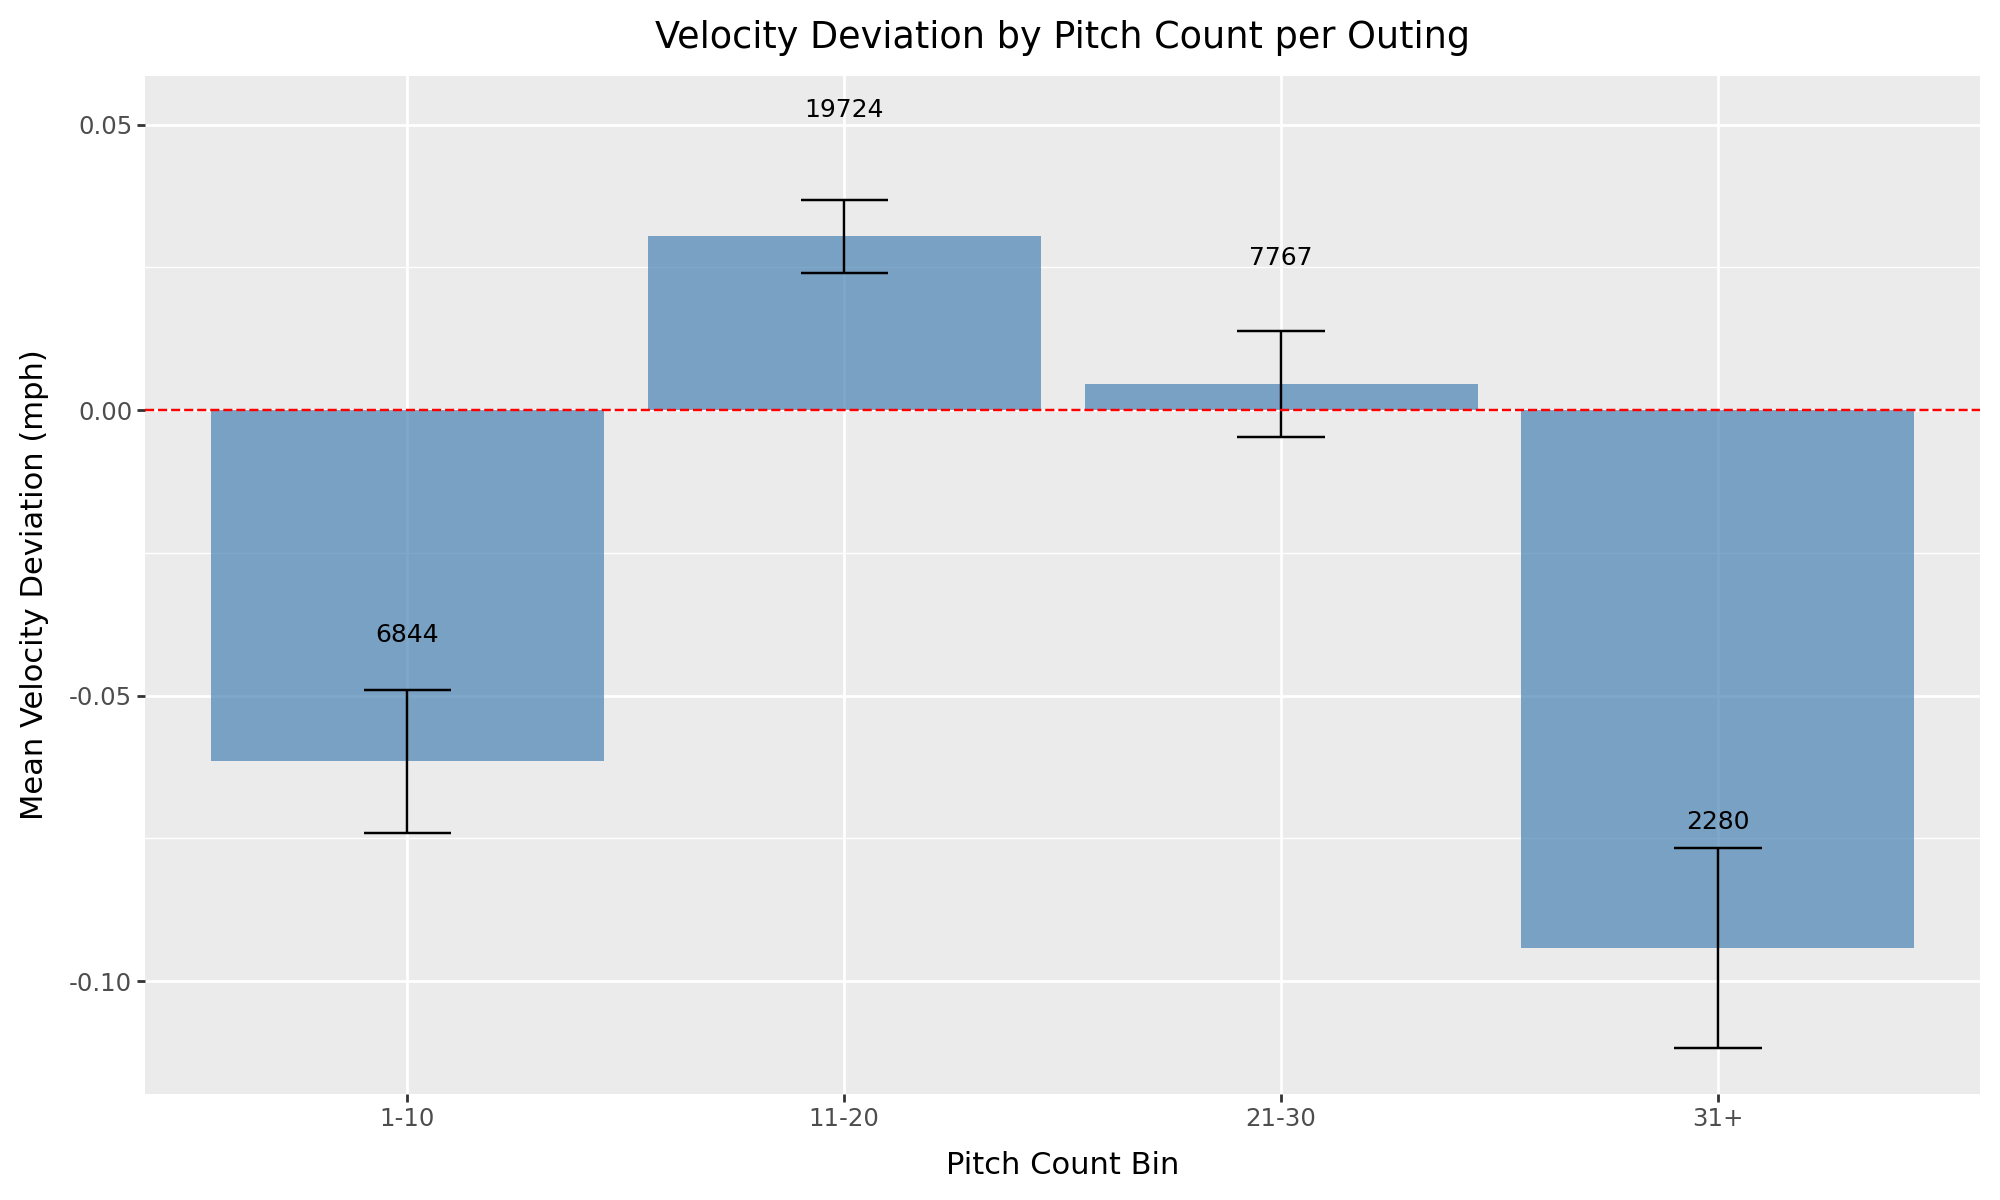

In [5]:
# 3. Bar chart with error bars
(ggplot(velo_by_pitch_count, aes(x='pitch_count_bin', y='mean_velo_dev')) +
 geom_col(fill='steelblue', alpha=0.7) +
 geom_errorbar(aes(ymin='mean_velo_dev - se', ymax='mean_velo_dev + se'), width=0.2) +
 geom_hline(yintercept=0, color='red', linetype='dashed') +
 geom_text(aes(label='count'), va='bottom', nudge_y=0.02, size=9) +
 labs(title='Velocity Deviation by Pitch Count per Outing',
      x='Pitch Count Bin',
      y='Mean Velocity Deviation (mph)') +
 theme(figure_size=(10, 6)))

### 1-10 could be pitchers getting pulled to struggling, testing to see if 31+ is stat significant

In [6]:
# 4. Statistical test: 31+ pitches vs moderate workload (11-20)
long_outings = pitch_count_bins.filter(pl.col('pitch_count_bin') == '31+')['velo_deviation'].to_numpy()
moderate_outings = pitch_count_bins.filter(pl.col('pitch_count_bin') == '11-20')['velo_deviation'].to_numpy()

t_stat, p_value = stats.ttest_ind(long_outings, moderate_outings)

print(f"Long outings (31+) vs Moderate (11-20)")
print(f"Mean difference: {long_outings.mean() - moderate_outings.mean():.4f} mph")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant: {p_value < 0.05}")
print(f"\nn(31+): {len(long_outings)}")
print(f"n(11-20): {len(moderate_outings)}")

Long outings (31+) vs Moderate (11-20)
Mean difference: -0.1246 mph
t-statistic: -6.387
p-value: 0.0000
Significant: True

n(31+): 2280
n(11-20): 19724


In [7]:
# 5. Calculate cumulative pitches BEFORE current outing
# 5. Calculate rolling pitch counts (previous 7/14/21/28 days, excluding current outing)
(outing_with_cumulative := (outing_data
    .sort(['pitcher_id', 'date'])
    .with_columns([
        pl.col('pitch_count')
        .rolling_sum_by('date', window_size='7d', closed='left')
        .over('pitcher_id')
        .alias('pitches_prev_7d'),
        
        pl.col('pitch_count')
        .rolling_sum_by('date', window_size='14d', closed='left')
        .over('pitcher_id')
        .alias('pitches_prev_14d'),
        
        pl.col('pitch_count')
        .rolling_sum_by('date', window_size='21d', closed='left')
        .over('pitcher_id')
        .alias('pitches_prev_21d'),
        
        pl.col('pitch_count')
        .rolling_sum_by('date', window_size='28d', closed='left')
        .over('pitcher_id')
        .alias('pitches_prev_28d')
    ])
)).select(['pitcher_name', 'date', 'pitch_count', 'pitches_prev_7d', 'pitches_prev_14d', 'pitches_prev_21d', 'pitches_prev_28d']).head(10)

pitcher_name,date,pitch_count,pitches_prev_7d,pitches_prev_14d,pitches_prev_21d,pitches_prev_28d
str,datetime[ns],u32,u32,u32,u32,u32
"""Yusmeiro Petit""",2021-04-06 00:00:00,16,null,null,null,null
"""Yusmeiro Petit""",2021-04-07 00:00:00,10,16,16,16,16
"""Yusmeiro Petit""",2021-04-09 00:00:00,8,26,26,26,26
"""Yusmeiro Petit""",2021-04-12 00:00:00,10,34,34,34,34
"""Yusmeiro Petit""",2021-04-13 00:00:00,6,44,44,44,44
"""Yusmeiro Petit""",2021-04-15 00:00:00,13,24,50,50,50
"""Yusmeiro Petit""",2021-04-16 00:00:00,19,37,63,63,63
"""Yusmeiro Petit""",2021-04-21 00:00:00,30,32,66,82,82
"""Yusmeiro Petit""",2021-04-23 00:00:00,21,49,86,112,112


In [8]:
# 6. Velocity deviation by cumulative 7-day workload (corrected rolling window)
# 6. Velocity deviation by all rolling workload windows
(workload_summary_7d := (outing_with_cumulative
    .with_columns([
        pl.when(pl.col('pitches_prev_7d') == 0).then(pl.lit('0'))
          .when(pl.col('pitches_prev_7d') <= 30).then(pl.lit('1-30'))
          .when(pl.col('pitches_prev_7d') <= 60).then(pl.lit('31-60'))
          .when(pl.col('pitches_prev_7d') <= 90).then(pl.lit('61-90'))
          .otherwise(pl.lit('91+')).alias('workload_bin')
    ])
    .group_by('workload_bin')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo_dev'),
        pl.col('velo_deviation').std().alias('std_velo_dev'),
        pl.len().alias('count'),
    ])
    .with_columns([
        (pl.col('std_velo_dev') / pl.col('count').sqrt()).alias('se'),
        pl.lit('7d').alias('window')
    ])
))

(workload_summary_14d := (outing_with_cumulative
    .with_columns([
        pl.when(pl.col('pitches_prev_14d') == 0).then(pl.lit('0'))
          .when(pl.col('pitches_prev_14d') <= 60).then(pl.lit('1-60'))
          .when(pl.col('pitches_prev_14d') <= 120).then(pl.lit('61-120'))
          .when(pl.col('pitches_prev_14d') <= 180).then(pl.lit('121-180'))
          .otherwise(pl.lit('181+')).alias('workload_bin')
    ])
    .group_by('workload_bin')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo_dev'),
        pl.col('velo_deviation').std().alias('std_velo_dev'),
        pl.len().alias('count'),
    ])
    .with_columns([
        (pl.col('std_velo_dev') / pl.col('count').sqrt()).alias('se'),
        pl.lit('14d').alias('window')
    ])
))

(workload_summary_21d := (outing_with_cumulative
    .with_columns([
        pl.when(pl.col('pitches_prev_21d') == 0).then(pl.lit('0'))
          .when(pl.col('pitches_prev_21d') <= 90).then(pl.lit('1-90'))
          .when(pl.col('pitches_prev_21d') <= 180).then(pl.lit('91-180'))
          .when(pl.col('pitches_prev_21d') <= 270).then(pl.lit('181-270'))
          .otherwise(pl.lit('271+')).alias('workload_bin')
    ])
    .group_by('workload_bin')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo_dev'),
        pl.col('velo_deviation').std().alias('std_velo_dev'),
        pl.len().alias('count'),
    ])
    .with_columns([
        (pl.col('std_velo_dev') / pl.col('count').sqrt()).alias('se'),
        pl.lit('21d').alias('window')
    ])
))

(workload_summary_28d := (outing_with_cumulative
    .with_columns([
        pl.when(pl.col('pitches_prev_28d') == 0).then(pl.lit('0'))
          .when(pl.col('pitches_prev_28d') <= 120).then(pl.lit('1-120'))
          .when(pl.col('pitches_prev_28d') <= 240).then(pl.lit('121-240'))
          .when(pl.col('pitches_prev_28d') <= 360).then(pl.lit('241-360'))
          .otherwise(pl.lit('361+')).alias('workload_bin')
    ])
    .group_by('workload_bin')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo_dev'),
        pl.col('velo_deviation').std().alias('std_velo_dev'),
        pl.len().alias('count'),
    ])
    .with_columns([
        (pl.col('std_velo_dev') / pl.col('count').sqrt()).alias('se'),
        pl.lit('28d').alias('window')
    ])
))

# Combine all four
workload_all = pl.concat([workload_summary_7d, workload_summary_14d, workload_summary_21d, workload_summary_28d])
workload_all

workload_bin,mean_velo_dev,std_velo_dev,count,se,window
str,f64,f64,u32,f64,str
"""31-60""",-0.001637,0.888434,19392,0.00638,"""7d"""
"""1-30""",0.024674,0.912415,12688,0.0081,"""7d"""
"""91+""",-0.115582,0.984024,1934,0.022376,"""7d"""
"""61-90""",-0.022212,0.862721,2601,0.016916,"""7d"""
"""121-180""",0.017158,0.93824,1194,0.027153,"""14d"""
…,…,…,…,…,…
"""181-270""",0.011486,0.959017,640,0.037908,"""21d"""
"""1-120""",-0.112298,0.944919,10089,0.009407,"""28d"""
"""241-360""",0.061306,0.978617,381,0.050136,"""28d"""


## Same pitcher in high workload vs small workload

In [9]:
# 8. Within-pitcher workload effect
(pitcher_workload_comparison := (outing_with_cumulative
    .with_columns([
        pl.when(pl.col('pitches_prev_7d') >= 60)
          .then(pl.lit('High'))
          .when(pl.col('pitches_prev_7d') <= 30)
          .then(pl.lit('Low'))
          .otherwise(pl.lit('Medium'))
          .alias('workload_category')
    ])
    .group_by(['pitcher_id', 'pitcher_name', 'workload_category'])
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo_dev'),
        pl.len().alias('count'),
    ])
    .filter(pl.col('count') >= 5)  # Only pitchers with 5+ outings in each category
)).head(3)


pitcher_id,pitcher_name,workload_category,mean_velo_dev,count
i64,str,str,f64,u32
676702,"""Hunter Stratton""","""Medium""",0.08272,17
445926,"""Jesse Chavez""","""Medium""",-0.016623,93
571521,"""Rex Brothers""","""Medium""",0.064289,32


In [13]:
pitcher_workload_comparison.write_csv('data/pitcher_workload_comparison.csv')

In [11]:
# Get pitchers who have both High and Low workload outings
pitchers_with_both = (pitcher_workload_comparison
    .pivot(index=['pitcher_id', 'pitcher_name'], columns='workload_category', values='mean_velo_dev')
    .drop_nulls(['High', 'Low'])
    .with_columns([
        (pl.col('High') - pl.col('Low')).alias('workload_effect')
    ])
)

pitchers_with_both.sort('workload_effect').head(5)

pitcher_id,pitcher_name,Medium,High,Low,workload_effect
i64,str,f64,f64,f64,f64
669387,"""Carmen Mlodzinski""",-0.064631,-0.827452,0.678735,-1.506187
676534,"""Calvin Faucher""",-0.144252,-0.624988,0.8318,-1.456789
656222,"""Jalen Beeks""",0.087559,-1.04492,0.385935,-1.430855
657585,"""Reed Garrett""",-0.129509,-0.821075,0.578815,-1.399889
681676,"""Ryan Fernandez""",0.239164,-1.012224,0.345731,-1.357954
